# Readability Score Analysis

This notebook computes the Flesch readability scores for the original and plain corpora using the same logic as `run_simple.py` and visualises the distribution with a Seaborn violin plot.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from paper_easy_plain_german_datasets.utils import process_folder

Matplotlib is building the font cache; this may take a moment.


In [2]:
from pathlib import Path

# Define the corpus directories (relative to the project root)
CRAWLED_ORIG = Path("data/crawled/orig")
CRAWLED_PLAIN = Path("data/crawled/plain")

# Disable caching for notebook runs to always compute fresh scores.
orig_scores = process_folder(CRAWLED_ORIG, use_cache=False)
plain_scores = process_folder(CRAWLED_PLAIN, use_cache=False)

Processing orig: 711it [00:39, 17.86it/s]
Processing plain: 707it [00:27, 25.56it/s]


In [3]:
# Prepare a DataFrame for plotting
import numpy as np

df = pd.DataFrame({
    "corpus": ["orig"] * len(orig_scores) + ["plain"] * len(plain_scores),
    "score": orig_scores + plain_scores,
})

/var/folders/tg/xf67d_9n1vg_l56xpl24mwzm0000gn/T/ipykernel_99562/1267371311.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="corpus", y="score", data=df, inner="quartile", palette="muted")


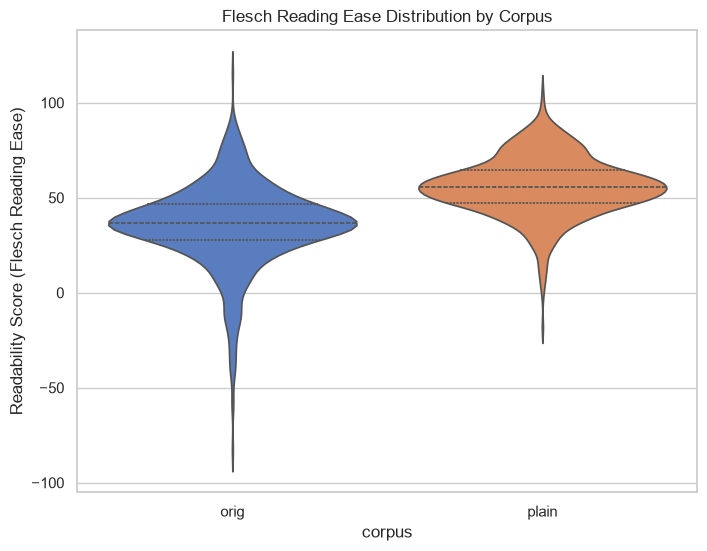

In [4]:
# Plot the distribution using a violin plot
sns.set(style="whitegrid")
plt.figure(figsize=(8, 6))
sns.violinplot(x="corpus", y="score", data=df, inner="quartile", palette="muted")
plt.title("Flesch Reading Ease Distribution by Corpus")
plt.ylabel("Readability Score (Flesch Reading Ease)")
plt.show()